In [3]:
import cv2
import numpy as np
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt

In [4]:
img = cv2.imread("skeleton_black_on_white.png", cv2.IMREAD_GRAYSCALE)

print(img.shape, img.dtype)

(926, 1171) uint8


In [5]:
import numpy as np
import cv2
from skimage.morphology import skeletonize
from skimage.util import img_as_ubyte

# ---------- IO helpers ----------
def load_yolo_detections(txt_path):
    dets = []
    with open(txt_path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            parts = line.strip().split()
            cls = int(parts[0])
            xc, yc, w, h = map(float, parts[1:5])
            conf = float(parts[5]) if len(parts) > 5 else None
            dets.append((cls, xc, yc, w, h, conf))
    return dets

def yolo_to_xyxy(xc, yc, w, h, W, H):
    # normalized -> pixel xyxy (inclusive-exclusive style)
    x1 = int(round((xc - w/2) * W))
    y1 = int(round((yc - h/2) * H))
    x2 = int(round((xc + w/2) * W))
    y2 = int(round((yc + h/2) * H))
    # clip
    x1 = max(0, min(W-1, x1))
    y1 = max(0, min(H-1, y1))
    x2 = max(0, min(W-1, x2))
    y2 = max(0, min(H-1, y2))
    # ensure proper ordering
    if x2 < x1: x1, x2 = x2, x1
    if y2 < y1: y1, y2 = y2, y1
    return x1, y1, x2, y2

# ---------- skeleton / endpoints helpers ----------
_NEIGH8 = [(-1,-1), (-1,0), (-1,1),
           ( 0,-1),         ( 0,1),
           ( 1,-1), ( 1,0), ( 1,1)]

def count_neighbors(skel, y, x):
    H, W = skel.shape
    c = 0
    for dy, dx in _NEIGH8:
        yy, xx = y+dy, x+dx
        if 0 <= yy < H and 0 <= xx < W and skel[yy, xx]:
            c += 1
    return c

def skeleton_endpoints_in_roi(skel, x1, y1, x2, y2):
    roi = skel[y1:y2+1, x1:x2+1]
    ys, xs = np.where(roi > 0)
    if len(xs) == 0:
        return np.empty((0,2), dtype=int)

    # endpoints = pixels with exactly 1 neighbor (in full image coords)
    eps = []
    for ry, rx in zip(ys, xs):
        gy, gx = y1 + ry, x1 + rx
        if count_neighbors(skel, gy, gx) == 1:
            eps.append((gx, gy))  # store as (x,y)
    return np.array(eps, dtype=int)

def farthest_pair(points_xy):
    # points_xy: (N,2) as (x,y)
    if len(points_xy) == 0:
        return None
    if len(points_xy) == 1:
        p = points_xy[0]
        return p, p
    # O(N^2) is ok for typical ROI sizes; if huge, we can optimize later
    diff = points_xy[:, None, :] - points_xy[None, :, :]
    d2 = (diff**2).sum(axis=2)
    i, j = np.unravel_index(np.argmax(d2), d2.shape)
    return points_xy[i], points_xy[j]

def boundary_pixels_xy(x1, y1, x2, y2):
    # all pixels along bbox border (x,y)
    xs_top = np.arange(x1, x2+1)
    ys_left = np.arange(y1, y2+1)
    top = np.stack([xs_top, np.full_like(xs_top, y1)], axis=1)
    bot = np.stack([xs_top, np.full_like(xs_top, y2)], axis=1)
    left = np.stack([np.full_like(ys_left, x1), ys_left], axis=1)
    right = np.stack([np.full_like(ys_left, x2), ys_left], axis=1)
    return np.unique(np.vstack([top, bot, left, right]), axis=0)

def skeleton_intersections_with_bbox_border(skel, x1, y1, x2, y2, tol=1):
    """
    Find skeleton pixels that lie on/near bbox border (tol pixels).
    """
    H, W = skel.shape
    # expanded border band
    xx1 = max(0, x1 - tol); yy1 = max(0, y1 - tol)
    xx2 = min(W-1, x2 + tol); yy2 = min(H-1, y2 + tol)

    # mask for border band: inside expanded box but outside inner box
    band = np.zeros_like(skel, dtype=bool)
    band[yy1:yy2+1, xx1:xx2+1] = True
    if x2 - x1 > 2*tol and y2 - y1 > 2*tol:
        band[y1+tol:y2-tol+1, x1+tol:x2-tol+1] = False

    ys, xs = np.where(skel & band)
    return np.stack([xs, ys], axis=1) if len(xs) else np.empty((0,2), dtype=int)

# ---------- main detection logic ----------
def detect_endpoints(image_path, txt_path, thresh=128):
    # Load grayscale image
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    H, W = gray.shape

    # Binary: black lines = 1
    binary = (gray < thresh).astype(np.uint8)

    # Skeletonize (expects bool)
    skel = skeletonize(binary.astype(bool)).astype(np.uint8)

    dets = load_yolo_detections(txt_path)

    results = []
    for cls, xc, yc, w, h, conf in dets:
        if cls == 0:
            continue  # skip as requested

        x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, W, H)

        if cls == 1:
            # endpoints from skeleton inside bbox
            eps = skeleton_endpoints_in_roi(skel, x1, y1, x2, y2)
            if len(eps) >= 2:
                # if more than 2, pick farthest 2
                p1, p2 = farthest_pair(eps)
            else:
                # fallback: farthest pair of all skeleton pixels in bbox
                roi = skel[y1:y2+1, x1:x2+1]
                ys, xs = np.where(roi > 0)
                pts = np.stack([x1+xs, y1+ys], axis=1) if len(xs) else np.empty((0,2), dtype=int)
                fp = farthest_pair(pts)
                if fp is None:
                    p1 = p2 = None
                else:
                    p1, p2 = fp

            results.append({
                "id": cls, "conf": conf, "bbox_xyxy": (x1,y1,x2,y2),
                "endpoint1_xy": None if p1 is None else tuple(map(int, p1)),
                "endpoint2_xy": None if p2 is None else tuple(map(int, p2)),
                "method": "cls1_skeleton_endpoints_or_farthest"
            })

        else:
            # intersection with bbox boundary (using skeleton on/near border)
            inter = skeleton_intersections_with_bbox_border(skel, x1, y1, x2, y2, tol=1)

            if len(inter) == 0:
                # fallback: use all skeleton pixels in bbox and pick farthest pair
                roi = skel[y1:y2+1, x1:x2+1]
                ys, xs = np.where(roi > 0)
                pts = np.stack([x1+xs, y1+ys], axis=1) if len(xs) else np.empty((0,2), dtype=int)
                fp = farthest_pair(pts)
                if fp is None:
                    p1 = p2 = None
                else:
                    p1, p2 = fp
                method = "bbox_no_border_hit_fallback_farthest_in_bbox"
            else:
                # if border intersections have endpoints, use them; else farthest pair on border
                # Try to keep only "endpoints" among intersection pixels
                eps = []
                for x, y in inter:
                    if count_neighbors(skel, y, x) == 1:
                        eps.append((x, y))
                eps = np.array(eps, dtype=int)

                if len(eps) >= 2:
                    p1, p2 = farthest_pair(eps)
                    method = "bbox_border_intersection_endpoints"
                else:
                    p1, p2 = farthest_pair(inter)
                    method = "bbox_border_intersection_farthest"

            results.append({
                "id": cls, "conf": conf, "bbox_xyxy": (x1,y1,x2,y2),
                "endpoint1_xy": None if p1 is None else tuple(map(int, p1)),
                "endpoint2_xy": None if p2 is None else tuple(map(int, p2)),
                "method": method
            })

    return results, skel

# --------- example usage ---------
image_path = "skeleton_black_on_white.png"  # change to your image path
txt_path = "/Users/mac/Downloads/LineDetect/ImageData/Imgtotest.txt"

results, skel = detect_endpoints(image_path, txt_path, thresh=128)

for r in results:
    print(r)


{'id': 1, 'conf': 0.767144, 'bbox_xyxy': (764, 753, 795, 782), 'endpoint1_xy': (795, 770), 'endpoint2_xy': (764, 771), 'method': 'cls1_skeleton_endpoints_or_farthest'}
{'id': 1, 'conf': 0.767722, 'bbox_xyxy': (917, 303, 945, 329), 'endpoint1_xy': (917, 319), 'endpoint2_xy': (933, 329), 'method': 'cls1_skeleton_endpoints_or_farthest'}
{'id': 1, 'conf': 0.787073, 'bbox_xyxy': (719, 314, 748, 343), 'endpoint1_xy': (719, 328), 'endpoint2_xy': (748, 329), 'method': 'cls1_skeleton_endpoints_or_farthest'}
{'id': 1, 'conf': 0.790539, 'bbox_xyxy': (271, 777, 303, 807), 'endpoint1_xy': (282, 777), 'endpoint2_xy': (303, 794), 'method': 'cls1_skeleton_endpoints_or_farthest'}
{'id': 1, 'conf': 0.805749, 'bbox_xyxy': (290, 330, 319, 359), 'endpoint1_xy': (319, 343), 'endpoint2_xy': (299, 359), 'method': 'cls1_skeleton_endpoints_or_farthest'}
{'id': 1, 'conf': 0.835907, 'bbox_xyxy': (951, 733, 985, 769), 'endpoint1_xy': (965, 733), 'endpoint2_xy': (951, 757), 'method': 'cls1_skeleton_endpoints_or_far

In [8]:
import matplotlib.pyplot as plt

gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

for r in results:
    x1,y1,x2,y2 = r["bbox_xyxy"]
    cv2.rectangle(vis, (x1,y1), (x2,y2), (0,255,0), 1)

    for k in ["endpoint1_xy", "endpoint2_xy"]:
        p = r[k]
        if p is not None:
            cv2.circle(vis, p, 4, (0,0,255), -1)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


KeyError: 'endpoint1_xy'

{'id': 1, 'conf': 0.767144, 'bbox_xyxy': (764, 753, 795, 782), 'endpoint_xy': (779, 768), 'method': 'cls1_center_snap_closest'}
{'id': 1, 'conf': 0.767722, 'bbox_xyxy': (917, 303, 945, 329), 'endpoint_xy': (932, 316), 'method': 'cls1_center_snap_closest'}
{'id': 1, 'conf': 0.787073, 'bbox_xyxy': (719, 314, 748, 343), 'endpoint_xy': (734, 329), 'method': 'cls1_center_snap_closest'}
{'id': 1, 'conf': 0.790539, 'bbox_xyxy': (271, 777, 303, 807), 'endpoint_xy': (286, 791), 'method': 'cls1_center_snap_closest'}
{'id': 1, 'conf': 0.805749, 'bbox_xyxy': (290, 330, 319, 359), 'endpoint_xy': (305, 344), 'method': 'cls1_center_snap_closest'}
{'id': 1, 'conf': 0.835907, 'bbox_xyxy': (951, 733, 985, 769), 'endpoint_xy': (968, 751), 'method': 'cls1_center_snap_closest'}
{'id': 12, 'conf': 0.858931, 'bbox_xyxy': (175, 559, 388, 633), 'endpoint1_xy': (287, 558), 'endpoint2_xy': (284, 634), 'method': 'border_hits_farthest_pair'}
{'id': 9, 'conf': 0.89978, 'bbox_xyxy': (466, 283, 613, 355), 'endpoint1_

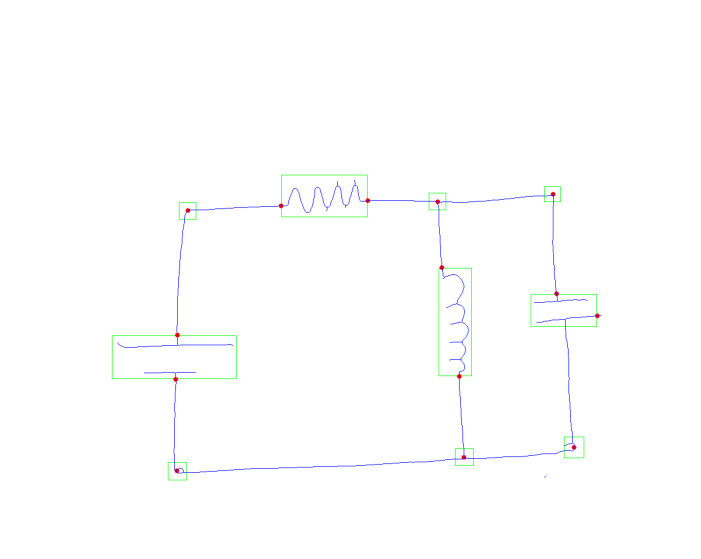

In [63]:
import numpy as np
import cv2
from skimage.morphology import skeletonize

# ---------------- IO helpers ----------------
def load_yolo_detections(txt_path):
    """
    Each line: cls xc yc w h conf   (all normalized except cls/conf)
    """
    dets = []
    with open(txt_path, "r") as f:
        for line in f:
            if not line.strip():
                continue
            parts = line.strip().split()
            cls = int(parts[0])
            xc, yc, w, h = map(float, parts[1:5])
            conf = float(parts[5]) if len(parts) > 5 else None
            dets.append((cls, xc, yc, w, h, conf))
    return dets

def yolo_to_xyxy(xc, yc, w, h, W, H):
    x1 = int(round((xc - w/2) * W))
    y1 = int(round((yc - h/2) * H))
    x2 = int(round((xc + w/2) * W))
    y2 = int(round((yc + h/2) * H))
    x1 = max(0, min(W-1, x1))
    y1 = max(0, min(H-1, y1))
    x2 = max(0, min(W-1, x2))
    y2 = max(0, min(H-1, y2))
    if x2 < x1: x1, x2 = x2, x1
    if y2 < y1: y1, y2 = y2, y1
    return x1, y1, x2, y2

# ---------------- Skeleton / geometry helpers ----------------
_NEIGH8 = [(-1,-1), (-1,0), (-1,1),
           ( 0,-1),         ( 0,1),
           ( 1,-1), ( 1,0), ( 1,1)]

def count_neighbors(skel, y, x):
    H, W = skel.shape
    c = 0
    for dy, dx in _NEIGH8:
        yy, xx = y+dy, x+dx
        if 0 <= yy < H and 0 <= xx < W and skel[yy, xx]:
            c += 1
    return c

def farthest_pair(points_xy):
    """
    points_xy: (N,2) array of (x,y)
    returns (p1, p2) as arrays (2,)
    """
    if points_xy is None or len(points_xy) == 0:
        return None
    if len(points_xy) == 1:
        return points_xy[0], points_xy[0]
    diff = points_xy[:, None, :] - points_xy[None, :, :]
    d2 = (diff**2).sum(axis=2)
    i, j = np.unravel_index(np.argmax(d2), d2.shape)
    return points_xy[i], points_xy[j]

def skeleton_intersections_with_bbox_border(skel, x1, y1, x2, y2, tol=1):
    """
    Return skeleton pixels that lie on/near the bbox border (within tol pixels).
    """
    H, W = skel.shape
    xx1 = max(0, x1 - tol); yy1 = max(0, y1 - tol)
    xx2 = min(W-1, x2 + tol); yy2 = min(H-1, y2 + tol)

    band = np.zeros_like(skel, dtype=bool)
    band[yy1:yy2+1, xx1:xx2+1] = True

    # carve out interior (keep only border band)
    if (x2 - x1) > 2*tol and (y2 - y1) > 2*tol:
        band[y1+tol:y2-tol+1, x1+tol:x2-tol+1] = False

    ys, xs = np.where((skel > 0) & band)
    if len(xs) == 0:
        return np.empty((0,2), dtype=int)
    return np.stack([xs, ys], axis=1)

def reduce_border_hits_to_two_endpoints(skel, inter_xy):
    """
    inter_xy: (N,2) array of (x,y) skeleton pixels near bbox border.
    Choose 2 endpoints robustly (can be 2+ points).
    """
    if len(inter_xy) == 0:
        return None, None, "no_border_hits"

    # Prefer true endpoints among border hits (degree==1)
    eps = []
    for x, y in inter_xy:
        if count_neighbors(skel, y, x) == 1:
            eps.append((x, y))
    eps = np.array(eps, dtype=int)

    if len(eps) >= 2:
        p1, p2 = farthest_pair(eps)
        return tuple(map(int, p1)), tuple(map(int, p2)), "border_hits_endpoint_degree1"
    else:
        p1, p2 = farthest_pair(inter_xy)
        return tuple(map(int, p1)), tuple(map(int, p2)), "border_hits_farthest_pair"

# ---------------- Class 1 (single endpoint) helpers ----------------
def nearest_skeleton_point_with_dist(skel, anchor_xy, search_xyxy):
    """
    Find nearest skeleton pixel to anchor_xy within search box.
    Returns (point_xy, squared_distance) or (None, None).
    """
    x1,y1,x2,y2 = search_xyxy
    roi = skel[y1:y2+1, x1:x2+1]
    ys, xs = np.where(roi > 0)
    if len(xs) == 0:
        return None, None

    pts = np.stack([x1+xs, y1+ys], axis=1)  # (N,2)
    ax, ay = anchor_xy
    d2 = (pts[:,0]-ax)**2 + (pts[:,1]-ay)**2
    i = int(np.argmin(d2))
    return tuple(map(int, pts[i])), float(d2[i])

def endpoint_for_class1_single(skel, x1, y1, x2, y2, margin=8):
    """
    Return ONE point for cls==1:
    - Take center of bbox
    - Find closest skeleton pixel to that center (within bbox expanded by margin)
    - Return (point_xy, method) in same format as before
    """
    H, W = skel.shape
    xc = int(round((x1 + x2) / 2))
    yc = int(round((y1 + y2) / 2))

    # expand search region to allow snapping just outside bbox
    sx1 = max(0, x1 - margin); sy1 = max(0, y1 - margin)
    sx2 = min(W - 1, x2 + margin); sy2 = min(H - 1, y2 + margin)

    p, d2 = nearest_skeleton_point_with_dist(skel, (xc, yc), (sx1, sy1, sx2, sy2))
    if p is None:
        return None, "cls1_no_skeleton_found"

    return p, "cls1_center_snap_closest"


# ---------------- Main pipeline ----------------
def detect_endpoints(image_path, txt_path, thresh=128, border_tol=1, cls1_margin=8):
    """
    - Builds skeleton from image (black pixels are foreground)
    - For cls==1: returns ONE endpoint (snapped to skeleton)
    - For cls!=0 and cls!=1: returns TWO endpoints using bbox-border intersections
    """
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    H, W = gray.shape

    binary = (gray < thresh).astype(np.uint8)
    skel = skeletonize(binary.astype(bool)).astype(np.uint8)

    dets = load_yolo_detections(txt_path)
    results = []

    for cls, xc, yc, w, h, conf in dets:
        if cls == 0:
            continue  # skip 0 as requested

        x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, W, H)

        if cls == 1:
            ep, method = endpoint_for_class1_single(skel, x1, y1, x2, y2, margin=cls1_margin)
            results.append({
                "id": cls,
                "conf": conf,
                "bbox_xyxy": (x1, y1, x2, y2),
                "endpoint_xy": ep,
                "method": method
            })
        else:
            inter = skeleton_intersections_with_bbox_border(skel, x1, y1, x2, y2, tol=border_tol)

            if len(inter) == 0:
                # fallback: use farthest pair of all skeleton pixels inside bbox
                roi = skel[y1:y2+1, x1:x2+1]
                ys, xs = np.where(roi > 0)
                pts = np.stack([x1+xs, y1+ys], axis=1) if len(xs) else np.empty((0,2), dtype=int)
                fp = farthest_pair(pts)
                if fp is None:
                    p1 = p2 = None
                    method = "bbox_no_border_hit_no_skeleton"
                else:
                    p1, p2 = tuple(map(int, fp[0])), tuple(map(int, fp[1]))
                    method = "bbox_no_border_hit_fallback_farthest_in_bbox"
            else:
                p1, p2, method = reduce_border_hits_to_two_endpoints(skel, inter)

            results.append({
                "id": cls,
                "conf": conf,
                "bbox_xyxy": (x1, y1, x2, y2),
                "endpoint1_xy": p1,
                "endpoint2_xy": p2,
                "method": method
            })

    return results, skel

# ---------------- Optional visualization ----------------
def visualize_results(image_path, results, skel=None, draw_skeleton=False):
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt

    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    for r in results:
        x1,y1,x2,y2 = r["bbox_xyxy"]
        cv2.rectangle(vis, (x1,y1), (x2,y2), (0,255,0), 1)

        if "endpoint_xy" in r:
            p = r["endpoint_xy"]
            if p is not None:
                cv2.circle(vis, p, 4, (0,0,255), -1)
        else:
            for k in ["endpoint1_xy", "endpoint2_xy"]:
                p = r.get(k, None)
                if p is not None:
                    cv2.circle(vis, p, 4, (0,0,255), -1)

    if draw_skeleton and skel is not None:
        ys, xs = np.where(skel > 0)
        vis[ys, xs] = (255, 0, 0)

    plt.figure(figsize=(12,7))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()


# ---------------- Example usage ----------------
image_path = "skeleton_black_on_white.png"  # <-- set this
txt_path = "/Users/mac/Downloads/LineDetect/ImageData/Imgtotest.txt"

results, skel = detect_endpoints(
    image_path=image_path,
    txt_path=txt_path,
    thresh=128,
    border_tol=1,
    cls1_margin=8
)

for r in results:
    print(r)

visualize_results(image_path, results, draw_skeleton=True, skel=skel)



In [18]:
print(results)

[{'id': 1, 'conf': 0.767144, 'bbox_xyxy': (764, 753, 795, 782), 'endpoint_xy': (779, 768), 'method': 'cls1_snap_closest'}, {'id': 1, 'conf': 0.767722, 'bbox_xyxy': (917, 303, 945, 329), 'endpoint_xy': (934, 314), 'method': 'cls1_snap_prefer_degree1'}, {'id': 1, 'conf': 0.787073, 'bbox_xyxy': (719, 314, 748, 343), 'endpoint_xy': (719, 328), 'method': 'cls1_snap_closest'}, {'id': 1, 'conf': 0.790539, 'bbox_xyxy': (271, 777, 303, 807), 'endpoint_xy': (286, 791), 'method': 'cls1_snap_closest'}, {'id': 1, 'conf': 0.805749, 'bbox_xyxy': (290, 330, 319, 359), 'endpoint_xy': (305, 344), 'method': 'cls1_snap_closest'}, {'id': 1, 'conf': 0.835907, 'bbox_xyxy': (951, 733, 985, 769), 'endpoint_xy': (951, 748), 'method': 'cls1_snap_prefer_degree1'}, {'id': 12, 'conf': 0.858931, 'bbox_xyxy': (175, 559, 388, 633), 'endpoint1_xy': (287, 558), 'endpoint2_xy': (284, 634), 'method': 'border_hits_farthest_pair'}, {'id': 9, 'conf': 0.89978, 'bbox_xyxy': (466, 283, 613, 355), 'endpoint1_xy': (614, 327), 'en

In [52]:
from collections import deque

# ---------------- Extract all endpoints from results ----------------
def extract_all_endpoints(results):
    """
    Extract all unique endpoints from results.
    Returns a list of (x, y) tuples.
    """
    endpoints = []
    for r in results:
        if "endpoint_xy" in r and r["endpoint_xy"] is not None:
            endpoints.append(r["endpoint_xy"])
        if "endpoint1_xy" in r and r["endpoint1_xy"] is not None:
            endpoints.append(r["endpoint1_xy"])
        if "endpoint2_xy" in r and r["endpoint2_xy"] is not None:
            endpoints.append(r["endpoint2_xy"])
    # Remove duplicates while preserving order
    seen = set()
    unique = []
    for ep in endpoints:
        if ep not in seen:
            seen.add(ep)
            unique.append(ep)
    return unique

# ---------------- BFS to find paths between endpoints ----------------
def bfs_find_paths_to_endpoints(skel, start_xy, all_endpoints, max_steps=100000):
    """
    BFS from start_xy on skeleton.
    When we reach any other endpoint, store the path and stop that branch.
    Continue exploring other branches.
    
    Returns:
        paths: dict mapping endpoint_xy -> list of (x,y) representing the path from start to that endpoint
    """
    H, W = skel.shape
    start = tuple(start_xy)
    
    # Convert endpoints to set for O(1) lookup (exclude start)
    target_endpoints = set(tuple(ep) for ep in all_endpoints if tuple(ep) != start)
    
    if not target_endpoints:
        return {}
    
    # BFS: queue contains (x, y, path_so_far)
    queue = deque()
    queue.append((start[0], start[1], [start]))
    
    visited = set()
    visited.add(start)
    
    found_paths = {}  # endpoint -> path
    
    # 8-connected neighbors
    neighbors = [(-1,-1), (-1,0), (-1,1),
                 ( 0,-1),         ( 0,1),
                 ( 1,-1), ( 1,0), ( 1,1)]
    
    steps = 0
    while queue and steps < max_steps:
        steps += 1
        x, y, path = queue.popleft()
        
        # Check if current position is a target endpoint
        if (x, y) in target_endpoints and (x, y) != start:
            found_paths[(x, y)] = path
            # Don't continue from this endpoint (stop this branch)
            continue
        
        # Explore neighbors
        for dy, dx in neighbors:
            nx, ny = x + dx, y + dy
            
            if 0 <= nx < W and 0 <= ny < H:
                if (nx, ny) not in visited and skel[ny, nx] > 0:
                    visited.add((nx, ny))
                    new_path = path + [(nx, ny)]
                    queue.append((nx, ny, new_path))
    
    return found_paths

# ---------------- Find all paths between all endpoint pairs ----------------
def find_all_endpoint_paths(skel, results):
    """
    Run BFS from each endpoint to find all connected endpoint pairs.
    Returns a list of dicts with path info.
    """
    endpoints = extract_all_endpoints(results)
    print(f"Found {len(endpoints)} unique endpoints: {endpoints}")
    
    all_paths = []
    processed_pairs = set()  # To avoid duplicate paths (A->B and B->A)
    
    for start_ep in endpoints:
        paths_from_start = bfs_find_paths_to_endpoints(skel, start_ep, endpoints)
        
        for end_ep, path in paths_from_start.items():
            # Create a canonical pair representation to avoid duplicates
            pair = tuple(sorted([start_ep, end_ep]))
            
            if pair not in processed_pairs:
                processed_pairs.add(pair)
                all_paths.append({
                    "start": start_ep,
                    "end": end_ep,
                    "path": path,
                    "length": len(path)
                })
                print(f"Path found: {start_ep} -> {end_ep}, length: {len(path)}")
    
    return all_paths, endpoints

# ---------------- Run BFS ----------------
all_paths, endpoints = find_all_endpoint_paths(skel, results)

print(f"\n=== Summary ===")
print(f"Total endpoints: {len(endpoints)}")
print(f"Total unique paths found: {len(all_paths)}")


Found 14 unique endpoints: [(779, 768), (932, 316), (734, 329), (286, 791), (305, 344), (968, 751), (287, 558), (284, 634), (614, 327), (465, 336), (741, 442), (771, 629), (938, 487), (1008, 525)]
Path found: (779, 768) -> (771, 629), length: 140
Path found: (779, 768) -> (968, 751), length: 194
Path found: (779, 768) -> (286, 791), length: 497
Path found: (779, 768) -> (284, 634), length: 654
Path found: (932, 316) -> (938, 487), length: 172
Path found: (932, 316) -> (734, 329), length: 200
Path found: (932, 316) -> (741, 442), length: 312
Path found: (932, 316) -> (614, 327), length: 320
Path found: (734, 329) -> (741, 442), length: 114
Path found: (734, 329) -> (614, 327), length: 121
Path found: (734, 329) -> (938, 487), length: 367
Path found: (286, 791) -> (284, 634), length: 160
Path found: (286, 791) -> (968, 751), length: 690
Path found: (305, 344) -> (465, 336), length: 161
Path found: (305, 344) -> (287, 558), length: 215
Path found: (968, 751) -> (1008, 525), length: 277
Pa

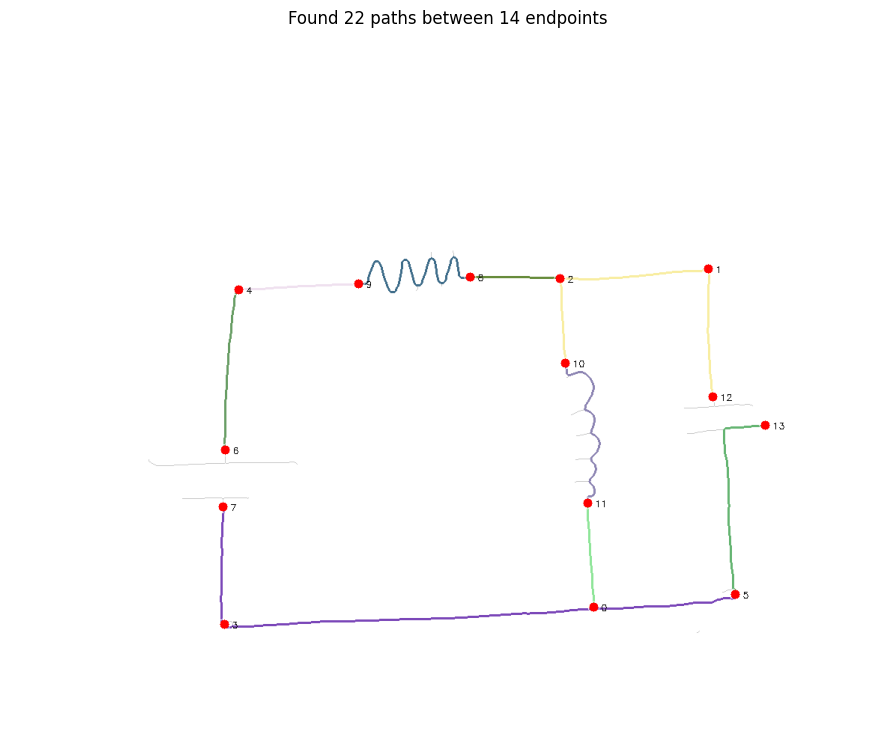


=== Path Details ===
Path 0: (779, 768) -> (771, 629), length=140
Path 1: (779, 768) -> (968, 751), length=194
Path 2: (779, 768) -> (286, 791), length=497
Path 3: (779, 768) -> (284, 634), length=654
Path 4: (932, 316) -> (938, 487), length=172
Path 5: (932, 316) -> (734, 329), length=200
Path 6: (932, 316) -> (741, 442), length=312
Path 7: (932, 316) -> (614, 327), length=320
Path 8: (734, 329) -> (741, 442), length=114
Path 9: (734, 329) -> (614, 327), length=121
Path 10: (734, 329) -> (938, 487), length=367
Path 11: (286, 791) -> (284, 634), length=160
Path 12: (286, 791) -> (968, 751), length=690
Path 13: (305, 344) -> (465, 336), length=161
Path 14: (305, 344) -> (287, 558), length=215
Path 15: (968, 751) -> (1008, 525), length=277
Path 16: (968, 751) -> (284, 634), length=847
Path 17: (614, 327) -> (741, 442), length=233
Path 18: (614, 327) -> (465, 336), length=328
Path 19: (614, 327) -> (938, 487), length=487
Path 20: (741, 442) -> (771, 629), length=224
Path 21: (741, 442) -

In [53]:
# ---------------- Visualize all paths ----------------
def visualize_paths(image_path, all_paths, endpoints, skel=None):
    """
    Visualize all found paths with different colors.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import cv2
    
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    
    # Draw skeleton in light gray
    if skel is not None:
        ys, xs = np.where(skel > 0)
        vis[ys, xs] = (200, 200, 200)
    
    # Generate distinct colors for each path
    np.random.seed(42)
    colors = []
    for _ in range(len(all_paths)):
        color = tuple(int(c) for c in np.random.randint(50, 255, 3))
        colors.append(color)
    
    # Draw each path with its color
    for i, path_info in enumerate(all_paths):
        path = path_info["path"]
        color = colors[i]
        
        # Draw path pixels
        for x, y in path:
            cv2.circle(vis, (x, y), 1, color, -1)
        
        # Draw thicker line connecting path points for visibility
        for j in range(len(path) - 1):
            pt1 = path[j]
            pt2 = path[j + 1]
            cv2.line(vis, pt1, pt2, color, 1)
    
    # Draw endpoints as larger circles
    for ep in endpoints:
        cv2.circle(vis, ep, 6, (0, 0, 255), -1)  # Red filled
        cv2.circle(vis, ep, 8, (255, 255, 255), 1)  # White border
    
    # Add text labels for endpoints
    for i, ep in enumerate(endpoints):
        cv2.putText(vis, str(i), (ep[0]+10, ep[1]+5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 1)
    
    plt.figure(figsize=(14, 9))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Found {len(all_paths)} paths between {len(endpoints)} endpoints")
    plt.axis("off")
    plt.show()
    
    # Print path details
    print("\n=== Path Details ===")
    for i, path_info in enumerate(all_paths):
        print(f"Path {i}: {path_info['start']} -> {path_info['end']}, length={path_info['length']}")

visualize_paths(image_path, all_paths, endpoints, skel)


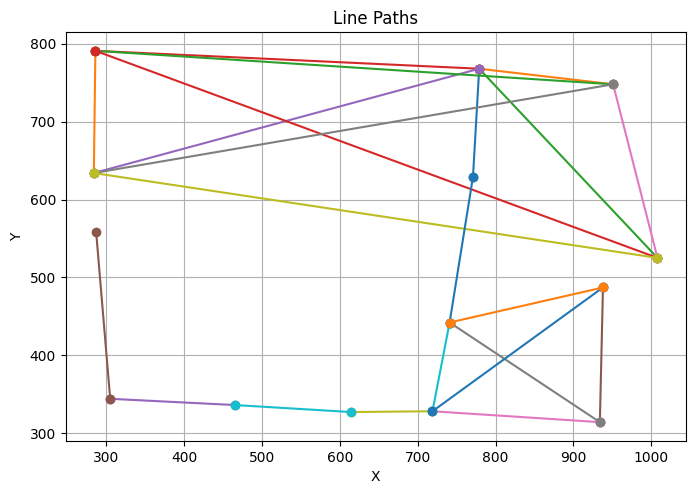

In [35]:
import matplotlib.pyplot as plt

# Define the paths as ((x1, y1), (x2, y2))
paths = [
    ((779, 768), (771, 629)),
    ((779, 768), (951, 748)),
    ((779, 768), (1008, 525)),
    ((779, 768), (286, 791)),
    ((779, 768), (284, 634)),
    ((934, 314), (938, 487)),
    ((934, 314), (719, 328)),
    ((934, 314), (741, 442)),
    ((719, 328), (614, 327)),
    ((719, 328), (741, 442)),
    ((719, 328), (938, 487)),
    ((286, 791), (284, 634)),
    ((286, 791), (951, 748)),
    ((286, 791), (1008, 525)),
    ((305, 344), (465, 336)),
    ((305, 344), (287, 558)),
    ((951, 748), (1008, 525)),
    ((951, 748), (284, 634)),
    ((284, 634), (1008, 525)),
    ((614, 327), (465, 336)),
    ((741, 442), (771, 629)),
    ((741, 442), (938, 487)),
]

plt.figure(figsize=(8, 8))

for (x1, y1), (x2, y2) in paths:
    plt.plot([x1, x2], [y1, y2], marker='o')

plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Line Paths")
plt.grid(True)

plt.show()


In [55]:
arrayendpoints = extract_all_endpoints(results)
print("All extracted endpoints:", arrayendpoints)

All extracted endpoints: [(779, 768), (932, 316), (734, 329), (286, 791), (305, 344), (968, 751), (287, 558), (284, 634), (614, 327), (465, 336), (741, 442), (771, 629), (938, 487), (1008, 525)]


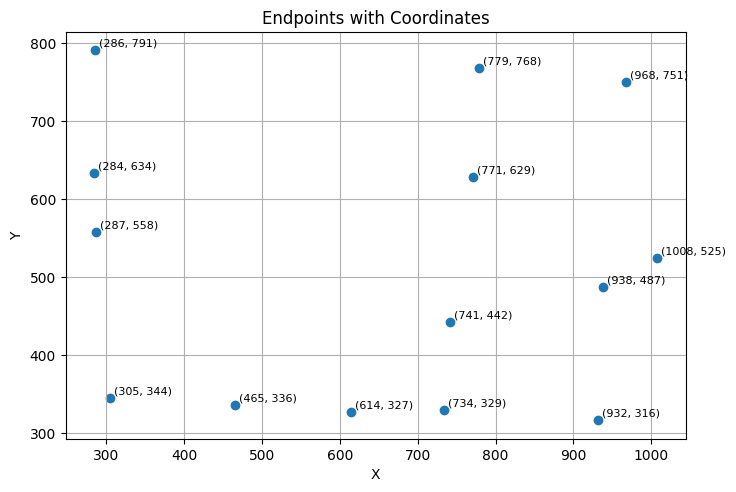

In [56]:
import matplotlib.pyplot as plt

# endpoints = [
#     (779, 768),
#     (934, 314),
#     (719, 328),
#     (286, 791),
#     (305, 344),
#     (951, 748),
#     (287, 558),
#     (284, 634),
#     (614, 327),
#     (465, 336),
#     (741, 442),
#     (771, 629),
#     (938, 487),
#     (1008, 525),
# ]

endpoints = arrayendpoints

plt.figure(figsize=(8, 8))

xs, ys = zip(*endpoints)
plt.scatter(xs, ys)

for x, y in endpoints:
    plt.text(x + 5, y + 5, f"({x}, {y})", fontsize=8)

plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Endpoints with Coordinates")
plt.grid(True)

plt.show()


In [60]:
from collections import deque

# ---------------- Union-Find (Disjoint Set Union) for tracking connectivity ----------------
class UnionFind:
    def __init__(self, elements):
        self.parent = {e: e for e in elements}
        self.rank = {e: 0 for e in elements}
    
    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])  # Path compression
        return self.parent[x]
    
    def union(self, x, y):
        px, py = self.find(x), self.find(y)
        if px == py:
            return False  # Already connected
        # Union by rank
        if self.rank[px] < self.rank[py]:
            px, py = py, px
        self.parent[py] = px
        if self.rank[px] == self.rank[py]:
            self.rank[px] += 1
        return True
    
    def connected(self, x, y):
        return self.find(x) == self.find(y)

# ---------------- BFS to find shortest path to any unconnected endpoint ----------------
def bfs_find_first_unconnected_endpoint(skel, start_xy, all_endpoints, uf, max_steps=100000):
    """
    BFS from start_xy on skeleton.
    Stop as soon as we find an endpoint that is NOT already connected to start in the Union-Find.
    
    Returns:
        (endpoint_xy, path) or (None, None) if no unconnected endpoint found
    """
    H, W = skel.shape
    start = tuple(start_xy)
    
    # All other endpoints (exclude start)
    target_endpoints = set(tuple(ep) for ep in all_endpoints if tuple(ep) != start)
    
    if not target_endpoints:
        return None, None
    
    queue = deque()
    queue.append((start[0], start[1], [start]))
    
    visited = set()
    visited.add(start)
    
    neighbors = [(-1,-1), (-1,0), (-1,1),
                 ( 0,-1),         ( 0,1),
                 ( 1,-1), ( 1,0), ( 1,1)]
    
    steps = 0
    while queue and steps < max_steps:
        steps += 1
        x, y, path = queue.popleft()
        
        # Check if current position is a target endpoint
        if (x, y) in target_endpoints:
            # Only return if NOT already connected (this would be a new edge in spanning tree)
            if not uf.connected(start, (x, y)):
                return (x, y), path
            # If already connected, stop this branch but continue others
            continue
        
        # Explore neighbors
        for dy, dx in neighbors:
            nx, ny = x + dx, y + dy
            
            if 0 <= nx < W and 0 <= ny < H:
                if (nx, ny) not in visited and skel[ny, nx] > 0:
                    visited.add((nx, ny))
                    new_path = path + [(nx, ny)]
                    queue.append((nx, ny, new_path))
    
    return None, None

# ---------------- Build spanning tree of paths ----------------
def build_spanning_tree_paths(skel, endpoints):
    """
    Build a minimal spanning tree of paths between endpoints.
    Uses Union-Find to avoid redundant/transitive paths.
    
    Returns:
        spanning_paths: list of path dicts (minimal non-redundant set)
    """
    # Initialize Union-Find with all endpoints
    endpoint_tuples = [tuple(ep) for ep in endpoints]
    uf = UnionFind(endpoint_tuples)
    
    spanning_paths = []
    
    # Keep exploring until no new connections can be made
    # We need at most (n-1) edges to connect n nodes
    max_edges = len(endpoints) - 1
    
    changed = True
    while changed and len(spanning_paths) < max_edges:
        changed = False
        
        for start_ep in endpoint_tuples:
            # Try to find an unconnected endpoint from this start
            end_ep, path = bfs_find_first_unconnected_endpoint(skel, start_ep, endpoint_tuples, uf)
            
            if end_ep is not None:
                # Found a new connection - add to spanning tree
                uf.union(start_ep, end_ep)
                spanning_paths.append({
                    "start": start_ep,
                    "end": end_ep,
                    "path": path,
                    "length": len(path)
                })
                print(f"Spanning edge found: {start_ep} -> {end_ep}, length: {len(path)}")
                changed = True
    
    return spanning_paths, uf

# ---------------- Run spanning tree algorithm ----------------
print("Building minimal spanning tree of paths...")
print(f"Input endpoints: {arrayendpoints}")
print()

spanning_paths, uf = build_spanning_tree_paths(skel, arrayendpoints)

print(f"\n=== Spanning Tree Summary ===")
print(f"Total endpoints: {len(arrayendpoints)}")
print(f"Spanning tree edges (paths): {len(spanning_paths)}")
print(f"Expected edges for full tree: {len(arrayendpoints) - 1}")

# Check connectivity
components = {}
for ep in arrayendpoints:
    root = uf.find(tuple(ep))
    if root not in components:
        components[root] = []
    components[root].append(ep)

print(f"\nConnected components: {len(components)}")
for i, (root, members) in enumerate(components.items()):
    print(f"  Component {i}: {len(members)} nodes")

Building minimal spanning tree of paths...
Input endpoints: [(779, 768), (932, 316), (734, 329), (286, 791), (305, 344), (968, 751), (287, 558), (284, 634), (614, 327), (465, 336), (741, 442), (771, 629), (938, 487), (1008, 525)]

Spanning edge found: (779, 768) -> (771, 629), length: 140
Spanning edge found: (932, 316) -> (938, 487), length: 172
Spanning edge found: (734, 329) -> (741, 442), length: 114
Spanning edge found: (286, 791) -> (284, 634), length: 160
Spanning edge found: (305, 344) -> (465, 336), length: 161
Spanning edge found: (968, 751) -> (779, 768), length: 194
Spanning edge found: (287, 558) -> (305, 344), length: 215
Spanning edge found: (284, 634) -> (779, 768), length: 654
Spanning edge found: (614, 327) -> (734, 329), length: 121
Spanning edge found: (465, 336) -> (614, 327), length: 328
Spanning edge found: (741, 442) -> (771, 629), length: 224
Spanning edge found: (938, 487) -> (734, 329), length: 367
Spanning edge found: (1008, 525) -> (968, 751), length: 277



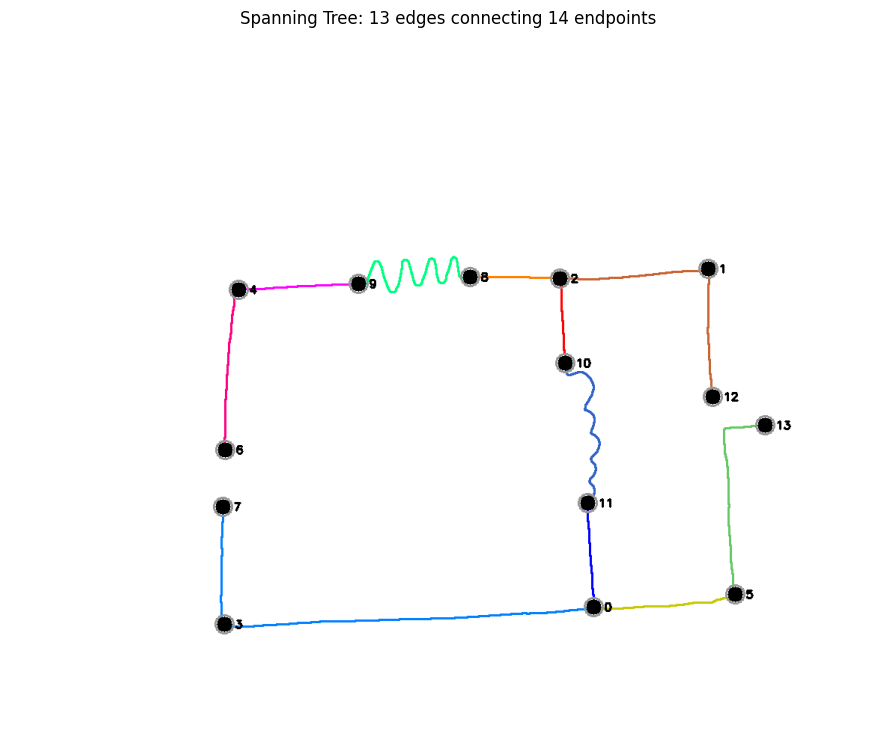


=== Spanning Tree Edges ===
Edge 0: Node 0 (779, 768) <-> Node 11 (771, 629), length=140
Edge 1: Node 1 (932, 316) <-> Node 12 (938, 487), length=172
Edge 2: Node 2 (734, 329) <-> Node 10 (741, 442), length=114
Edge 3: Node 3 (286, 791) <-> Node 7 (284, 634), length=160
Edge 4: Node 4 (305, 344) <-> Node 9 (465, 336), length=161
Edge 5: Node 5 (968, 751) <-> Node 0 (779, 768), length=194
Edge 6: Node 6 (287, 558) <-> Node 4 (305, 344), length=215
Edge 7: Node 7 (284, 634) <-> Node 0 (779, 768), length=654
Edge 8: Node 8 (614, 327) <-> Node 2 (734, 329), length=121
Edge 9: Node 9 (465, 336) <-> Node 8 (614, 327), length=328
Edge 10: Node 10 (741, 442) <-> Node 11 (771, 629), length=224
Edge 11: Node 12 (938, 487) <-> Node 2 (734, 329), length=367
Edge 12: Node 13 (1008, 525) <-> Node 5 (968, 751), length=277


In [61]:
# ---------------- Visualize spanning tree paths on canvas ----------------
def draw_spanning_tree_on_canvas(spanning_paths, endpoints, canvas_size, background_color=(255, 255, 255)):
    """
    Draw the spanning tree paths on a clean canvas.
    """
    import numpy as np
    import cv2
    import matplotlib.pyplot as plt
    
    H, W = canvas_size
    canvas = np.full((H, W, 3), background_color, dtype=np.uint8)
    
    # Colors for paths
    colors = [
        (255, 0, 0),    # Blue
        (0, 200, 0),    # Green
        (0, 0, 255),    # Red
        (255, 200, 0),  # Cyan
        (255, 0, 255),  # Magenta
        (0, 200, 200),  # Yellow
        (128, 0, 255),  # Purple
        (255, 128, 0),  # Light blue
        (0, 128, 255),  # Orange
        (128, 255, 0),  # Lime
        (200, 100, 50), # Brown-blue
        (50, 100, 200), # Dark orange
        (100, 200, 100),# Light green
    ]
    
    # Draw each spanning path
    for i, path_info in enumerate(spanning_paths):
        path = path_info["path"]
        color = colors[i % len(colors)]
        
        # Draw as polyline
        if len(path) >= 2:
            pts = np.array(path, dtype=np.int32)
            cv2.polylines(canvas, [pts], isClosed=False, color=color, thickness=2)
    
    # Draw endpoints
    for i, ep in enumerate(endpoints):
        ep = tuple(ep)
        cv2.circle(canvas, ep, 10, (0, 0, 0), -1)      # Black filled
        cv2.circle(canvas, ep, 12, (150, 150, 150), 2)  # Gray border
        # Label
        cv2.putText(canvas, str(i), (ep[0] + 14, ep[1] + 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)
    
    plt.figure(figsize=(14, 9))
    plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    plt.title(f"Spanning Tree: {len(spanning_paths)} edges connecting {len(endpoints)} endpoints")
    plt.axis("off")
    plt.show()
    
    return canvas

# Get canvas size
gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
canvas_size = gray.shape

# Draw spanning tree
spanning_canvas = draw_spanning_tree_on_canvas(spanning_paths, arrayendpoints, canvas_size)

# Print the spanning tree edges
print("\n=== Spanning Tree Edges ===")
for i, p in enumerate(spanning_paths):
    start_idx = arrayendpoints.index(p["start"]) if p["start"] in arrayendpoints else "?"
    end_idx = arrayendpoints.index(p["end"]) if p["end"] in arrayendpoints else "?"
    print(f"Edge {i}: Node {start_idx} {p['start']} <-> Node {end_idx} {p['end']}, length={p['length']}")

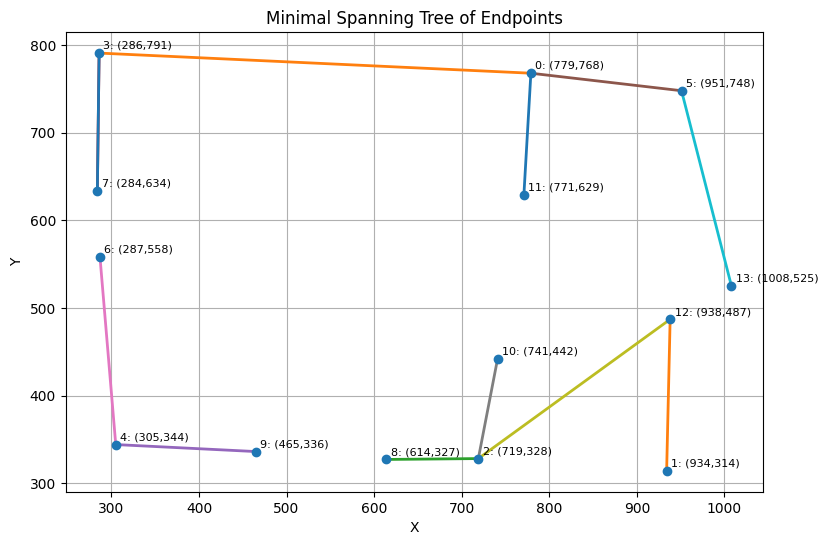

In [44]:
import matplotlib.pyplot as plt

# Endpoints (node index -> coordinate)
endpoints = [
    (779, 768),   # 0
    (934, 314),   # 1
    (719, 328),   # 2
    (286, 791),   # 3
    (305, 344),   # 4
    (951, 748),   # 5
    (287, 558),   # 6
    (284, 634),   # 7
    (614, 327),   # 8
    (465, 336),   # 9
    (741, 442),   # 10
    (771, 629),   # 11
    (938, 487),   # 12
    (1008, 525),  # 13
]

# Spanning tree edges (index pairs)
edges = [
    (0, 11),
    (1, 12),
    (2, 8),
    (3, 7),
    (4, 9),
    (5, 0),
    (6, 4),
    # (7, 0),
    # (8, 9),
    (10, 2),
    # (11, 10),
    (12, 2),
    (13, 5),
    (7,3),
    (3,0),
]

plt.figure(figsize=(9, 9))

# Plot edges
for i, j in edges:
    x1, y1 = endpoints[i]
    x2, y2 = endpoints[j]
    plt.plot([x1, x2], [y1, y2], linewidth=2)

# Plot endpoints
xs, ys = zip(*endpoints)
plt.scatter(xs, ys, zorder=3)

# Label endpoints
for idx, (x, y) in enumerate(endpoints):
    plt.text(x + 5, y + 5, f"{idx}: ({x},{y})", fontsize=8)

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Minimal Spanning Tree of Endpoints")
plt.grid(True)

plt.show()


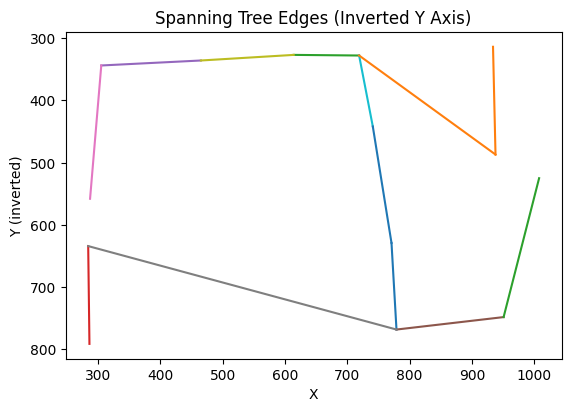

In [46]:
import matplotlib.pyplot as plt

edges = [
    ((779, 768), (771, 629)),
    ((934, 314), (938, 487)),
    ((719, 328), (614, 327)),
    ((286, 791), (284, 634)),
    ((305, 344), (465, 336)),
    ((951, 748), (779, 768)),
    ((287, 558), (305, 344)),
    ((284, 634), (779, 768)),
    ((614, 327), (465, 336)),
    ((741, 442), (719, 328)),
    ((771, 629), (741, 442)),
    ((938, 487), (719, 328)),
    ((1008, 525), (951, 748)),
]

plt.figure()
for (x1, y1), (x2, y2) in edges:
    plt.plot([x1, x2], [y1, y2])

ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
ax.invert_yaxis()  # invert Y like image coordinates

plt.xlabel("X")
plt.ylabel("Y (inverted)")
plt.title("Spanning Tree Edges (Inverted Y Axis)")
plt.show()


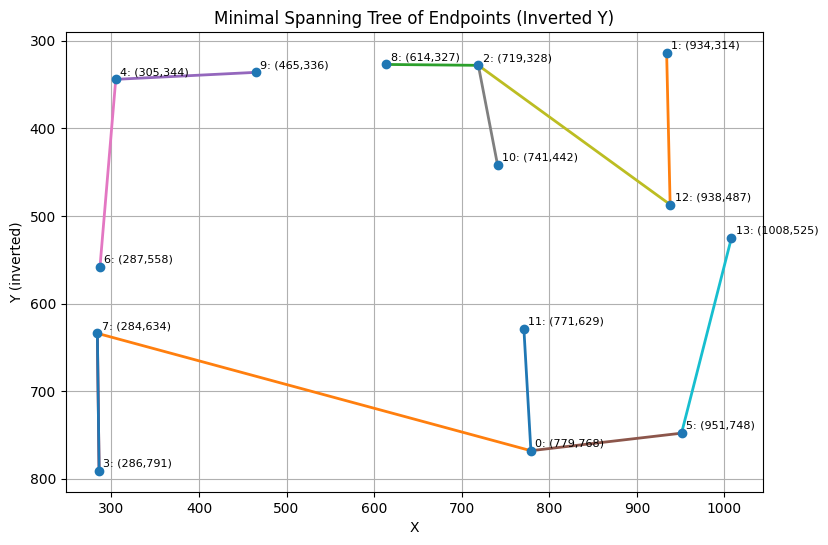

In [50]:
import matplotlib.pyplot as plt

# Endpoints (node index -> coordinate)
endpoints = [
    (779, 768),   # 0
    (934, 314),   # 1
    (719, 328),   # 2
    (286, 791),   # 3
    (305, 344),   # 4
    (951, 748),   # 5
    (287, 558),   # 6
    (284, 634),   # 7
    (614, 327),   # 8
    (465, 336),   # 9
    (741, 442),   # 10
    (771, 629),   # 11
    (938, 487),   # 12
    (1008, 525),  # 13
]

# Spanning tree edges (index pairs)
edges = [
    (0, 11),
    (1, 12),
    (2, 8),
    (3, 7),
    (4, 9),
    (5, 0),
    (6, 4),
    # (7, 0),
    # (8, 9),
    (10, 2),
    # (11, 10),
    (12, 2),
    (13, 5),
    (7, 3),
    (7, 0),
]

plt.figure(figsize=(9, 9))

# Plot edges
for i, j in edges:
    x1, y1 = endpoints[i]
    x2, y2 = endpoints[j]
    plt.plot([x1, x2], [y1, y2], linewidth=2)

# Plot endpoints
xs, ys = zip(*endpoints)
plt.scatter(xs, ys, zorder=3)

# Label endpoints (offset adjusted for inverted Y)
for idx, (x, y) in enumerate(endpoints):
    plt.text(x + 5, y - 5, f"{idx}: ({x},{y})", fontsize=8)

ax = plt.gca()
ax.set_aspect("equal", adjustable="box")
ax.invert_yaxis()  # 👈 inverted Y axis (image-style coordinates)

plt.xlabel("X")
plt.ylabel("Y (inverted)")
plt.title("Minimal Spanning Tree of Endpoints (Inverted Y)")
plt.grid(True)

plt.show()
